***Coding Sample***

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
pDF = pd.read_excel('/Users/shawnlu/main/cmu/research/project/Coattail effect/data/raw_data/France_President_17.xlsx')
lDF = pd.read_excel('/Users/shawnlu/main/cmu/research/project/Coattail effect/data/raw_data/France_Parliament_17.xlsx')

In [18]:
tempDf = pd.read_excel('/Users/shawnlu/main/cmu/research/project/Coattail effect/data/raw_data/France_Parliament_17.xlsx')

In [19]:
tempDf2 = tempDf[tempDf['tour'] == 'Résultats de la circonscription au 2d tour *']
tempDf1 = tempDf[tempDf['tour'] == 'Rappel des résultats de la circonscription au 1er tour *']
print(int((tempDf1['Nuances'] == 'MDM').sum()))
print(int((tempDf1['Nuances'] == 'REM').sum()))

print(int((tempDf2['Nuances'] == 'MDM').sum()))
print(int((tempDf2['Nuances'] == 'REM').sum()))

69
466
62
454


In [20]:
tempDf = tempDf.groupby(['Provence', 'circonscription'])

In [21]:
tempDf.size()

Provence  circonscription     
Ain       1ère circonscription    12
          2ème circonscription    12
          3ème circonscription    13
          4ème circonscription    16
          5ème circonscription    15
                                  ..
Yvelines  5ème circonscription    14
          6ème circonscription    16
          7ème circonscription    16
          8ème circonscription    19
          9ème circonscription    18
Length: 577, dtype: int64

In [22]:
pDF_first = pDF[pDF['tour'] == '*Rappel des résultats du département au 1er tour']

pDF_first_lepen = pDF_first[pDF_first['candidats'] == 'Mme Marine LE PEN']
pDF_first_macron = pDF_first[pDF_first['candidats'] == 'M. Emmanuel MACRON']
pDF_first_fillon = pDF_first[pDF_first['candidats'] == 'M. François FILLON']
pDF_first_Melenchon = pDF_first[pDF_first['candidats'] == 'M. Jean-Luc MÉLENCHON']
pDF_first_Hamon = pDF_first[pDF_first['candidats'] == 'M. Benoît HAMON']


pDF_first = pDF_first_lepen.merge(pDF_first_macron, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.merge(pDF_first_fillon, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={'Voix_x': 'LePen_votes',
                            'Inscrits_x': '%LePen_registered_share',
                            'Exprimés_x': '%LePen_share',
                            'Voix_y': 'Macron_votes',
                            'Inscrits_y': '%Macron_registered_share',
                            'Exprimés_y': '%Macron_share',
                            'Voix': 'Fillon_votes',
                            'Inscrits': '%Fillon_registered_share',
                            'Exprimés': '%Fillon_share'})
pDF_first = pDF_first.drop(['candidats_x', 'candidats_y'], axis=1)
pDF_first = pDF_first.merge(pDF_first_Melenchon, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={
                            'Voix': 'Melenchon_votes',
                            'Inscrits': '%Melenchon_registered_share',
                            'Exprimés': '%Melenchon_share'})
pDF_first = pDF_first.merge(pDF_first_Hamon, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={
                            'Voix': 'Hamon_votes',
                            'Inscrits': '%Hamon_registered_share',
                            'Exprimés': '%Hamon_share'})
pDF_first = pDF_first.drop(['candidats'], axis=1)



In [23]:
pDF_Second = pDF[pDF['tour'] == '* Résultats du département au 2d tour']

pDF_second_lepen = pDF_Second[pDF_Second['candidats'] == 'Mme Marine LE PEN']
pDF_second_macron = pDF_Second[pDF_Second['candidats'] == 'M. Emmanuel MACRON']
pDF_Second = pDF_second_lepen.merge(pDF_second_macron, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])

pDF_Second = pDF_Second.rename(columns={'Voix_x': 'LePen_votes',
                            'Inscrits_x': '%LePen_registered_share',
                            'Exprimés_x': '%LePen_share',
                            'Voix_y': 'Macron_votes',
                            'Inscrits_y': '%Macron_registered_share',
                            'Exprimés_y': '%Macron_share'})
pDF_Second = pDF_Second.drop(['candidats_x', 'candidats_y'], axis=1)

In [24]:
lDF_first = lDF[lDF['tour'] == 'Rappel des résultats de la circonscription au 1er tour *']
lDF_first_FN = lDF_first[lDF_first['Nuances'] == 'FN']
lDF_first_MDM = lDF_first[lDF_first['Nuances'].isin(['MDM', 'REM'])]
lDF_first_LR = lDF_first[lDF_first['Nuances'] == 'LR']
lDF_first_FI = lDF_first[lDF_first['Nuances'] == 'FI']
lDF_first_PS = lDF_first[lDF_first['Nuances'].isin(['SOC', 'RDG', 'ECO', 'DVG'])]
print(lDF_first_FN.shape)
print(lDF_first_MDM.shape)
print(lDF_first_LR.shape)
print(lDF_first_FI.shape)
# print(lDF_first_PS.shape)

(568, 11)
(535, 11)
(478, 11)
(554, 11)


In [ ]:
lDF_first = lDF[lDF['tour'] == 'Rappel des résultats de la circonscription au 1er tour *']
lDF_first_FN = lDF_first[lDF_first['Nuances'] == 'FN']
lDF_first_FN = lDF_first_FN.rename(columns={'Voix': 'FN_votes',
                                            'Inscrits': '%FN_registered_share',
                                            'Exprimés': '%FN_share'})
lDF_first_FN['total_votes'] = lDF_first_FN['FN_votes'] / lDF_first_FN['%FN_share'] * 100
lDF_first_FN['total_votes'] = lDF_first_FN['total_votes'].round(0)
lDF_first_FN = lDF_first_FN.groupby('Provence')[['FN_votes', 'total_votes']].sum()
lDF_first_FN['%FN_share'] = lDF_first_FN['FN_votes'] / lDF_first_FN['total_votes'] * 100

lDF_first_MDM = lDF_first[lDF_first['Nuances'].isin(['MDM', 'REM'])]
lDF_first_MDM['total_votes'] = (lDF_first_MDM['Voix'] / lDF_first_MDM['Exprimés'] * 100)
lDF_first_MDM['total_votes'] = lDF_first_MDM['total_votes'].round(0)
lDF_first_MDM = lDF_first_MDM.groupby('Provence')[['Voix', 'total_votes']].sum()
lDF_first_MDM['%MDM_share'] = lDF_first_MDM['Voix'] / lDF_first_MDM['total_votes'] * 100

lDF_first_LR = lDF_first[lDF_first['Nuances'] == 'LR']
lDF_first_LR['total_votes'] = (lDF_first_LR['Voix'] / lDF_first_LR['Exprimés'] * 100)
lDF_first_LR['total_votes'] = lDF_first_LR['total_votes'].round(0)
lDF_first_LR = lDF_first_LR.groupby('Provence')[['Voix', 'total_votes']].sum()
lDF_first_LR['%LR_share'] = lDF_first_LR['Voix'] / lDF_first_LR['total_votes'] * 100

lDF_first_FI = lDF_first[lDF_first['Nuances'] == 'FI']
lDF_first_FI['total_votes'] = (lDF_first_FI['Voix'] / lDF_first_FI['Exprimés'] * 100)
lDF_first_FI['total_votes'] = lDF_first_FI['total_votes'].round(0)
lDF_first_FI = lDF_first_FI.groupby('Provence')[['Voix', 'total_votes']].sum()
lDF_first_FI['%FI_share'] = lDF_first_FI['Voix'] / lDF_first_FI['total_votes'] * 100
lDF_first_FI = lDF_first_FI.rename(columns={'Voix': 'FI_votes'})
lDF_first_FI = lDF_first_FI.drop('total_votes', axis=1)

lDF_first_PS = lDF_first[lDF_first['Nuances'].isin(['SOC', 'RDG', 'ECO', 'DVG'])]
lDF_first_PS['total_votes'] = (lDF_first_PS['Voix'] / lDF_first_PS['Exprimés'] * 100)
lDF_first_PS['total_votes'] = lDF_first_PS['total_votes'].round(0)
lDF_first_PS = lDF_first_PS.groupby('Provence')[['Voix', 'total_votes']].sum()
lDF_first_PS['%PS_share'] = lDF_first_PS['Voix'] / lDF_first_PS['total_votes'] * 100
lDF_first_PS = lDF_first_PS.rename(columns={'Voix': 'PS_votes'})
lDF_first_PS = lDF_first_PS.drop('total_votes', axis=1)

lDF_merge = lDF_first_FN.merge(lDF_first_MDM, left_on='Provence', right_on='Provence')
lDF_merge = lDF_merge.merge(lDF_first_LR, left_on='Provence', right_on='Provence')
lDF_merge = lDF_merge.merge(lDF_first_FI, left_on='Provence', right_on='Provence')
lDF_merge = lDF_merge.merge(lDF_first_PS, left_on='Provence', right_on='Provence')

ESP of FN: 9.040262034125128
ESP of MDM: 9.8714211290215
ESP of LR: 3.8527761033875945
ESP of FI: 8.208324541142572

Mean Gap of FN: 9.040262034125128
Mean Gap of MDM: -9.349634786221836
Mean Gap of LR: 0.5305324255380617
Mean Gap of FI: 8.208324541142572


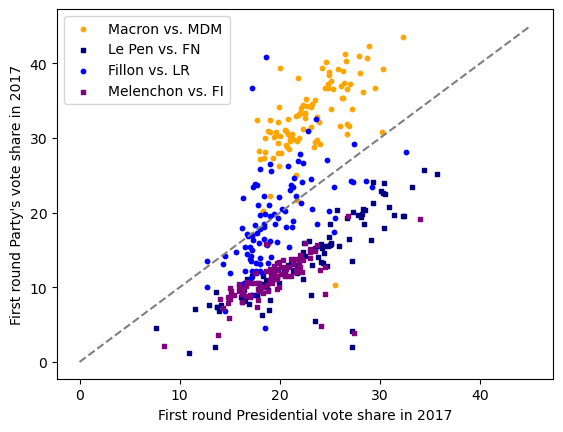

In [26]:
mergeDF_first = pDF_first.merge(lDF_merge, left_on='Provence', right_on='Provence')
mergeDF_first['FN_ESP'] = abs(mergeDF_first['%LePen_share'] - mergeDF_first['%FN_share'])
mergeDF_first['MDM_ESP'] = abs(mergeDF_first['%Macron_share'] - mergeDF_first['%MDM_share'])
mergeDF_first['LR_ESP'] = abs(mergeDF_first['%Fillon_share'] - mergeDF_first['%LR_share'])
mergeDF_first['FI_ESP'] = abs(mergeDF_first['%Melenchon_share'] - mergeDF_first['%FI_share'])
# mergeDF_first['PS_ESP'] = abs(mergeDF_first['%Hamon_share'] - mergeDF_first['%PS_share'])

mergeDF_first['FN_gap'] = (mergeDF_first['%LePen_share'] - mergeDF_first['%FN_share'])
mergeDF_first['MDM_gap'] = (mergeDF_first['%Macron_share'] - mergeDF_first['%MDM_share'])
mergeDF_first['LR_gap'] = (mergeDF_first['%Fillon_share'] - mergeDF_first['%LR_share'])
mergeDF_first['FI_gap'] = (mergeDF_first['%Melenchon_share'] - mergeDF_first['%FI_share'])
# mergeDF_first['PS_gap'] = (mergeDF_first['%Hamon_share'] - mergeDF_first['%PS_share'])

print(f'ESP of FN: {mergeDF_first['FN_ESP'].mean()}')
print(f'ESP of MDM: {mergeDF_first['MDM_ESP'].mean()}')
print(f'ESP of LR: {mergeDF_first['LR_ESP'].mean()}')
print(f'ESP of FI: {mergeDF_first['FI_ESP'].mean()}')
# print(f'ESP of PS: {mergeDF_first['PS_ESP'].mean()}')
print()
print(f'Mean Gap of FN: {mergeDF_first['FN_gap'].mean()}')
print(f'Mean Gap of MDM: {mergeDF_first['MDM_gap'].mean()}')
print(f'Mean Gap of LR: {mergeDF_first['LR_gap'].mean()}')
print(f'Mean Gap of FI: {mergeDF_first['FI_gap'].mean()}')
# print(f'Mean Gap of PS: {mergeDF_first['PS_gap'].mean()}')

plt.scatter(mergeDF_first['%Macron_share'], mergeDF_first['%MDM_share'], s=10, color='orange', label='Macron vs. MDM')
plt.scatter(mergeDF_first['%LePen_share'], mergeDF_first['%FN_share'], marker='s', s=10, color='navy', label='Le Pen vs. FN')
plt.scatter(mergeDF_first['%Fillon_share'], mergeDF_first['%LR_share'], s=10, color='blue', label='Fillon vs. LR')
plt.scatter(mergeDF_first['%Melenchon_share'], mergeDF_first['%FI_share'], marker='s', s=10, color='purple', label='Melenchon vs. FI')
# plt.scatter(mergeDF_first['%Hamon_share'], mergeDF_first['%PS_share'], s=10, color='red', label='Hamon vs. PS')

plt.plot([0, 45], [0, 45], color='gray', linestyle='--')
plt.legend()
plt.xlabel('First round Presidential vote share in 2017')
plt.ylabel("First round Party's vote share in 2017")
plt.show()

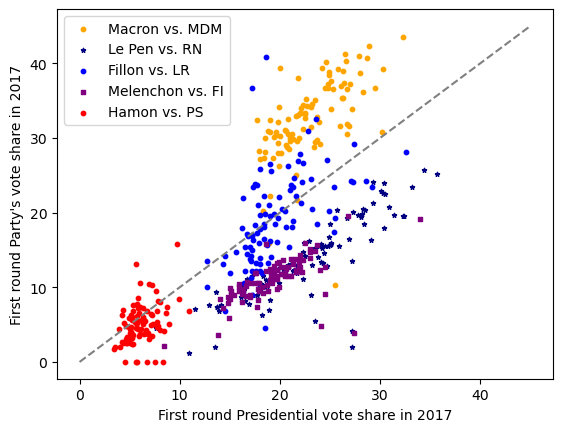

In [27]:
plt.scatter(mergeDF_first['%Macron_share'], mergeDF_first['%MDM_share'], s=10, color='orange', label='Macron vs. MDM')
plt.scatter(mergeDF_first['%LePen_share'], mergeDF_first['%FN_share'], marker='*', s=10, color='navy', label='Le Pen vs. RN')
plt.scatter(mergeDF_first['%Fillon_share'], mergeDF_first['%LR_share'], s=10, color='blue', label='Fillon vs. LR')
plt.scatter(mergeDF_first['%Melenchon_share'], mergeDF_first['%FI_share'], marker='s', s=10, color='purple', label='Melenchon vs. FI')
plt.scatter(mergeDF_first['%Hamon_share'], mergeDF_first['%PS_share'], s=10, color='red', label='Hamon vs. PS')

plt.plot([0, 45], [0, 45], color='gray', linestyle='--')
plt.legend()
plt.xlabel('First round Presidential vote share in 2017')
plt.ylabel("First round Party's vote share in 2017")
plt.show()

ESP of FN: 22.593017136165937
ESP of MDM: 31.53261011173735


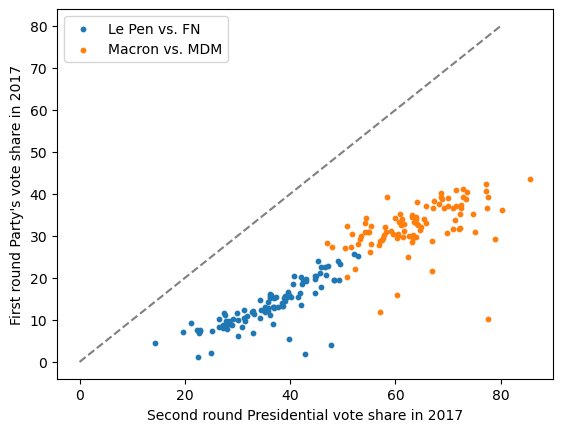

In [28]:
mergeDF_first = pDF_Second.merge(lDF_merge, left_on='Provence', right_on='Provence')
mergeDF_first['FN_ESP'] = abs(mergeDF_first['%LePen_share'] - mergeDF_first['%FN_share'])
mergeDF_first['MDM_ESP'] = abs(mergeDF_first['%Macron_share'] - mergeDF_first['%MDM_share'])

print(f'ESP of FN: {mergeDF_first['FN_ESP'].mean()}')
print(f'ESP of MDM: {mergeDF_first['MDM_ESP'].mean()}')
plt.scatter(mergeDF_first['%LePen_share'], mergeDF_first['%FN_share'], s=10, label='Le Pen vs. FN')
plt.scatter(mergeDF_first['%Macron_share'], mergeDF_first['%MDM_share'], s=10, label='Macron vs. MDM')
plt.plot([0, 80], [0, 80], color='gray', linestyle='--')
plt.legend()
plt.xlabel('Second round Presidential vote share in 2017')
plt.ylabel("First round Party's vote share in 2017")
plt.show()